In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import jax
import jax.numpy as jnp
import optax
import scipy.io as sio
from typing import Tuple, Callable, Any

# Import from tvboptim
from tvboptim.types import Parameter, BoundedParameter
from tvboptim.experimental.network_dynamics.graph import DenseGraph
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.experimental.network_dynamics.result import NativeSolution
from tvboptim.experimental.network_dynamics.core.bunch import Bunch

from tvboptim.experimental.network_dynamics.coupling.base import InstantaneousCoupling
from tvboptim.experimental.network_dynamics.dynamics.base import AbstractDynamics

from tvboptim.optim.optax import OptaxOptimizer
from tvboptim.optim.callbacks import MultiCallback, DefaultPrintCallback, SavingLossCallback
from tvboptim.experimental.network_dynamics.core.bunch import Bunch
# Observation functions
from tvboptim.observations.observation import compute_fc, fc_corr, rmse
from tvboptim.utils import set_cache_path, cache

from tvboptim.observations.tvb_monitors.bold import Bold

# Import later built utility functions
from utils import z_score_per_region, lagged_fc_matrices

In [5]:
jax.config.update("jax_enable_x64", True)

In [6]:
# Set directory information
data_dir = "./"
cond0_filename = "TS_Control.npy"
cond1_filename = "TS_Schizo.npy"

# Set dataset parameters
n_sub = 48
n_nodes = 68 # size of network for AAL90
conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

# Simulation parameters
t1 = 314_000   # Simulation duration (ms) matching empirical data (=304_000) + transient time (~10_000 ms)
dt = 4.0      # Integration timestep (ms) matching original script
bold_TR = 2000.0 # BOLD sampling period (ms)
target_fic = 0.25  # FIC tuning parameter: Target excitatory activity level

# Gradient descent parameters
learning_rate = 0.0325
max_steps = 120

# Other parameters
n_tau = 2 # number of lags for lagged FC

In [7]:
TS_CTR  = np.load('TS_Control.npy')
TS_SCZ  = np.load('TS_Schizo.npy')
print(TS_CTR.shape)

# Separate the participants by condition
condition_0 = TS_CTR[0:n_sub, 0:n_nodes, :]  # all participants (condition 0)
condition_1 = TS_SCZ[:, 0:n_nodes, :]  # Last 48 participants (condition 1)

# Determine the maximum number of participants in either condition (for alignment)
max_participants = max(condition_0.shape[2], condition_1.shape[2])

# Pad the smaller group to match the size of the larger one along the participant dimension
condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

# Stack the conditions along the fourth dimension
new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

(116, 82, 152)


In [8]:
participant_idx = 0
condition_idx = 0

# Get empirical time series of interest 
ts = new_array[participant_idx,:,:,condition_idx]
# Take the transpose for the lagged FC matrices computation
X_emp = ts.T
print("Empirical time series shape (time points x regions):", X_emp.shape)

# Z-score the empirical time series per region
z_scored_emp = z_score_per_region(X_emp)

# Compute empirical lagged FC matrices
Q_emp = lagged_fc_matrices(z_scored_emp, n_tau=2, diag_zero=True)
Q0_emp = Q_emp[0]  # FC0 (zero-lag)
Q1_emp = Q_emp[1]  # FC1 (lag-1)

Empirical time series shape (time points x regions): (152, 68)


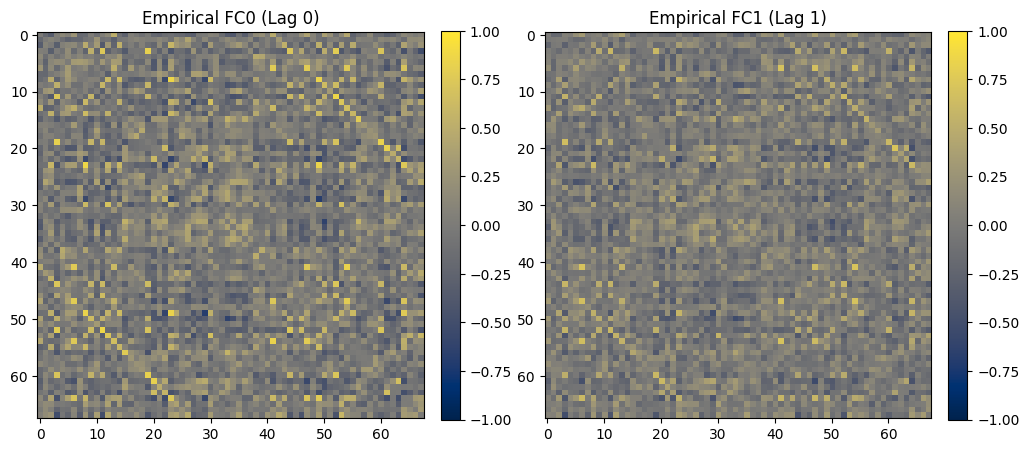

In [9]:
# Plot FC 0 and FC 1 for both empirical and simulated data
fig, axes = plt.subplots(1,2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0].imshow(Q0_emp, vmin=-1, vmax=1, cmap='cividis')
axes[0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1].imshow(Q1_emp, vmin=-1, vmax=1, cmap='cividis')
axes[1].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

In [10]:
# Weights
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
weights = SCR / np.max(SCR)

# Delays
lengths = pd.read_csv('tract_lengths.csv')
speed = 3.0
delays = lengths / speed

# Load region labels and coordinates
df = pd.read_csv(
    'centers.txt',
    sep='\t',
    header=None,
    dtype={1: float, 2: float, 3: float},
    names=['label', 'x', 'y', 'z']
)

labels = df['label'].tolist()

In [11]:
class ReducedWongWangEIB(AbstractDynamics):
    """Two-population Reduced Wong-Wang model with E-I balance support"""

    STATE_NAMES = ('S_e', 'S_i')
    INITIAL_STATE = (0.001, 0.001)
    AUXILIARY_NAMES = ('H_e', 'H_i')
    g_prop = 0  # awake

    DEFAULT_PARAMS = Bunch(
        # Excitatory population parameters
        a_e=310.0,         # Input gain parameter
        b_e=125.0,         # Input shift parameter [Hz]
        d_e=0.160,         # Input scaling parameter [s]
        gamma_e=0.641/1000,  # Kinetic parameter
        tau_e=100.0,       # NMDA decay time constant [ms]
        w_p   = 1.4 * (1 - 0.2*g_prop),           # Excitatory recurrence weight
        W_e=1.0,           # External input scaling weight

        # Inhibitory population parameters
        a_i=615.0,         # Input gain parameter
        b_i=177.0,         # Input shift parameter [Hz]
        d_i=0.087,         # Input scaling parameter [s]
        gamma_i=1.0/1000,  # Kinetic parameter
        tau_i = 10  * (1 + 0.8*g_prop),        # NMDA decay time constant [ms]
        W_i=0.7,           # External input scaling weight

        # Synaptic weights
        J_N=0.15,          # NMDA current [nA]
        J_i   = 1.0 * (1 + 0.6*g_prop),          # Inhibitory synaptic weight

        # External inputs
        I_o=0.382,         # Background input current
        I_ext=0.0,         # External stimulation current

        # Coupling parameters
        lamda=1.0,         # Lambda: inhibitory coupling scaling

    )

# Primary GABA effect
#J_i = 1.0 → 1.4
# Slower inhibition
#tau_i = 10.0 → 18.0
# Slightly reduced excitation
#w_p = 1.4 → 1.2

    COUPLING_INPUTS = {
        'coupling': 2,  # Long-range excitation and Feedforward inhibition
    }

    def dynamics(
        self,
        t: float,
        state: jnp.ndarray,
        params: Bunch,
        coupling: Bunch,
        external: Bunch
    ) -> Tuple[jnp.ndarray, jnp.ndarray]:
        """Compute two-population Wong-Wang dynamics with dual coupling."""

        # Unpack state variables
        S_e = state[0]  # Excitatory synaptic gating
        S_i = state[1]  # Inhibitory synaptic gating

        # Unpack coupling inputs
        c_lre = params.J_N * coupling.coupling[0]  # Long-range excitation
        c_ffi = params.J_N * coupling.coupling[1]  # Feedforward inhibition

        # Excitatory population input
        J_N_S_e = params.J_N * S_e
        x_e_pre = (params.w_p * J_N_S_e - params.J_i * S_i +
                   params.W_e * params.I_o + c_lre + params.I_ext)

        # Excitatory transfer function
        x_e = params.a_e * x_e_pre - params.b_e
        H_e = x_e / (1.0 - jnp.exp(-params.d_e * x_e))

        # Excitatory dynamics
        dS_e_dt = -(S_e / params.tau_e) + (1.0 - S_e) * H_e * params.gamma_e

        # Inhibitory population input
        x_i_pre = J_N_S_e - S_i + params.W_i * params.I_o + params.lamda * c_ffi

        # Inhibitory transfer function
        x_i = params.a_i * x_i_pre - params.b_i
        H_i = x_i / (1.0 - jnp.exp(-params.d_i * x_i))

        # Inhibitory dynamics
        dS_i_dt = -(S_i / params.tau_i) + H_i * params.gamma_i

        # Package results
        derivatives = jnp.array([dS_e_dt, dS_i_dt])
        auxiliaries = jnp.array([H_e, H_i])

        return derivatives, auxiliaries
    
class EIBLinearCoupling(InstantaneousCoupling):
    """EIB Linear coupling with separate excitatory and inhibitory weight matrices.

    This coupling produces two outputs:
        c_lre: Long-range excitation (wLRE * S_e)
        c_ffi: Feedforward inhibition (wFFI * S_e)

    Both couplings are driven by the excitatory activity (S_e) from other regions.
    """

    N_OUTPUT_STATES = 2  # Produces two coupling outputs

    DEFAULT_PARAMS = Bunch(
        wLRE = 1.0,  # Long-range excitation weight matrix
        wFFI = 1.0,  # Feedforward inhibition weight matrix
    )

    def pre(
        self,
        incoming_states: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Pre-synaptic transformation: multiply S_e with wLRE and wFFI."""
        # incoming_states[0] is S_e from all source nodes
        S_e = incoming_states[0]  # [n_target, n_source]
        # Apply weights: element-wise multiply S_e with each weight matrix
        # params.wLRE and params.wFFI have shape [n_nodes, n_nodes]
        c_lre = S_e * params.wLRE  # [n_target, n_source]
        c_ffi = S_e * params.wFFI  # [n_target, n_source]

        # Stack into [2, n_target, n_source]
        return jnp.stack([c_lre, c_ffi], axis=0)

    def post(
        self,
        summed_inputs: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Post-synaptic transformation: pass through without scaling."""
        return summed_inputs
    


In [12]:
# Create network components
graph = DenseGraph(weights, region_labels=labels)
dynamics = ReducedWongWangEIB(J_i = jnp.ones((n_nodes)))

# Initialize EIB coupling with dual weight matrices
# wLRE and wFFI start as copies of structural connectivity
coupling = EIBLinearCoupling(incoming_states=["S_e"])

# Set the weight matrices to the proper shape based on structural connectivity
# Both start as scaled versions of structural connectivity
coupling.params.wLRE = jnp.ones((n_nodes, n_nodes)) #+ 0.8*fc_target  # [n_nodes, n_nodes]
coupling.params.wFFI = jnp.ones((n_nodes, n_nodes)) #- 0.8*fc_target  # [n_nodes, n_nodes]

# Small noise to break symmetry
noise = AdditiveNoise(sigma=0.01, apply_to="S_e")

# Assemble the network
network = Network(
    dynamics=dynamics,
    coupling={'coupling': coupling},  # Both use same coupling but produce different outputs
    graph=graph,
    noise=noise
)

print(f"Network created with {n_nodes} nodes")

Network created with 68 nodes


In [13]:
# Prepare simulation: compile model and initialize state
t1 = 314_000   # Simulation duration (ms) - 1 minute for initial transient
dt = 4.0      # Integration timestep (ms) matching original script
solver = BoundedSolver(Heun(), low=0.0, high=1.0)
model, state = prepare(network, solver, t1=t1, dt=dt)

# Run initial transient to reach quasi-stationary state
print("Running initial transient simulation...")
result_init = jax.block_until_ready(model(state))

# Update network with final state as new initial conditions
network.update_history(result_init)

# Prepare for shorter simulations used in EI tuning
bold_TR = 2000.0

# Create BOLD monitor - we'll monitor S_e (first state variable)
# The BOLD period is bold_TR
bold_monitor = Bold(
    period=bold_TR,           # BOLD sampling period (TR = 2000 ms)
    downsample_period=4.0,  # Intermediate downsampling matches dt
    voi=0,                  # Monitor first state variable (S_e)
    history=result_init     # Use initial state as warm start for BOLD history
)

print("BOLD monitor initialized")

Running initial transient simulation...
BOLD monitor initialized


In [14]:
# Prepare simulation
solver_opt = BoundedSolver(Heun(), low=0.0, high=1.0)
model_opt, state_opt = prepare(network, solver_opt, t1=t1, dt=dt)

# FIC tuning parameter
target_fic = 0.25  # Target excitatory activity level

# Create BOLD monitor
bold_monitor_opt = Bold(
    period=bold_TR,
    downsample_period=4.0,
    voi=0,
    history=result_init
)

print("Optimization model prepared")

# Define loss function for optimization

Optimization model prepared


In [15]:
# Single loss with heavier FC1
beta_fc1 = 2.0
alpha_fc0 = 1.0

def loss(state):
    ts = model_opt(state)
    bold = bold_monitor_opt(ts)

    bold_signal = bold.data
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    bold_signal = bold_signal[5:, :]
    z_scored_bold = z_score_per_region(bold_signal)

    Qsim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim, Q1_sim = Qsim[0], Qsim[1]

    loss_q0 = rmse(Q0_sim, Q0_emp)
    loss_q1 = rmse(Q1_sim, Q1_emp)

    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    return alpha_fc0 * loss_q0 + beta_fc1 * loss_q1 + activity_loss

In [16]:
# Evaluate initial loss
initial_loss = loss(state_opt)
print(f"Initial loss: {initial_loss:.4f}")

# Mark parameters for optimization (J_i, wLRE, wFFI) with appropriate constraints
state_opt.dynamics.J_i = Parameter(state_opt.dynamics.J_i)
state_opt.coupling.coupling.wLRE = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)
state_opt.coupling.coupling.wFFI = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)


Initial loss: 1.0224


In [17]:
# Hyperparameters
max_steps = 120
learning_rate = 0.0325

In [18]:
optimizer_test = OptaxOptimizer(
    loss,
    optax.adamaxw(learning_rate=learning_rate),
    callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
)

optimized_state, optimized_fit = optimizer_test.run(state_opt, max_steps=max_steps)

Step 0: 1.022387
Step 1: 0.990873
Step 2: 0.949785


KeyboardInterrupt: 